In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

from tqdm.notebook import tqdm

In [2]:
result_dir = "/Users/chanb/research/ualberta/hint_rl/data/hint_rl_run"
main_log = os.path.join(result_dir, "main.log")

epoch = 1
epoch_step = 1
train_step = 1
all_rows = []
rows = []
with open(main_log, "r") as f:
    for line in tqdm(f):
        if "INFO: Updated hint percentages:" in line:
            for key_val in line.split("{")[1].split("}")[0].split(","):
                key, val = key_val.split(":")
                key = int(key.strip())
                val = float(val.strip())
                rows.append({
                    "sample_idx": key,
                    "hint_percentage": val,
                })
                has_added = True

        if "StatsLogger INFO: Epoch" in line and "done." in line:
            epoch = int(line.split("Epoch ")[1].split("/")[0])
            train_step = int(line.split("Train step ")[1].split("/")[0])
            epoch_step = int(line.split("Step ")[1].split("/")[0])

            rows = [dict(**row, epoch=epoch, train_step=train_step, epoch_step=epoch_step) for row in rows]
            all_rows.extend(rows)
            rows = []

df = pd.DataFrame(all_rows)

0it [00:00, ?it/s]

In [3]:
df

,sample_idx,hint_percentage,epoch,train_step,epoch_step
0,13,1.0,1,1,1
1,58,1.0,1,1,1
2,63,1.0,1,1,1
3,70,1.0,1,1,1
4,71,1.0,1,1,1
...,...,...,...,...,...
283584,278,1.0,12,166,12
283585,1658,1.0,12,166,12
283586,438,0.6,12,166,12
283587,1672,0.8,12,166,12


In [4]:
epochs = np.sort(df.epoch.unique())
sample_idxes = np.sort(df.sample_idx.unique())
hint_percentages = np.sort(df.hint_percentage.unique())

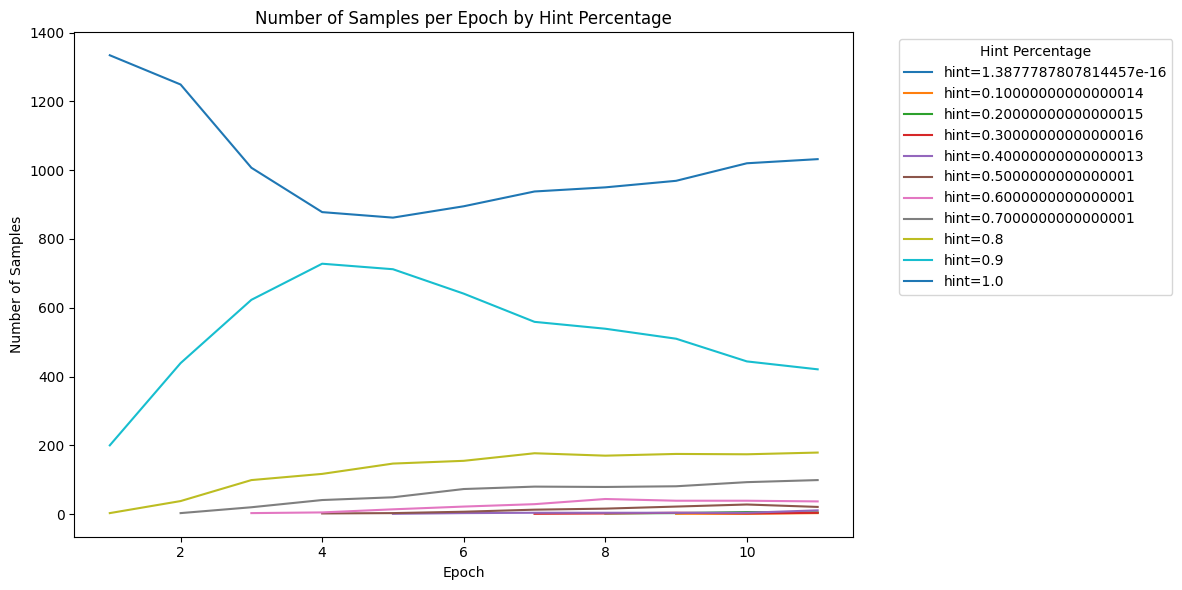

In [11]:
# Group by epoch and hint_percentage, count number of samples
sub_df = df[df.train_step % max(df.epoch_step.unique()) == 0]
grouped = sub_df.groupby(['epoch', 'hint_percentage'])['sample_idx'].count().reset_index()
grouped.columns = ['epoch', 'hint_percentage', 'num_samples']

# Pivot so each hint_percentage becomes a column
pivoted = grouped.pivot(index='epoch', columns='hint_percentage', values='num_samples')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

for hint_pct in pivoted.columns:
    ax.plot(pivoted.index, pivoted[hint_pct], label=f'hint={hint_pct}')

ax.set_xlabel('Epoch')
ax.set_ylabel('Number of Samples')
ax.set_title('Number of Samples per Epoch by Hint Percentage')
ax.legend(title='Hint Percentage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
# Perhaps the same question is being sampled multiple times---need to check.
df[df.epoch == 1].hint_percentage.unique()

array([1. , 0.9, 0.8])

In [15]:
# Get the last epoch_step for each epoch
last_step = df[df['epoch_step'] == df.groupby('epoch')['epoch_step'].transform('max')]

# Pivot: rows = sample_idx, columns = epoch, values = hint_percentage
pivoted = last_step.pivot_table(index='sample_idx', columns='epoch', values='hint_percentage')

# Compute diff between consecutive epochs (epoch+1 minus epoch)
epoch_diff = pivoted.diff(axis=1)

# Result: each column is the diff from the previous epoch
# Drop the first epoch column (no previous epoch to diff against)
epoch_diff = epoch_diff.drop(columns=pivoted.columns[0])
epoch_diff

epoch,2,3,4,5,6,7,8,9,10,11,12
sample_idx,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,-0.2,-0.1,-0.1,0.0,0.1,0.0,-0.1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.1
2,-0.1,0.1,0.0,-0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,-0.1,0.0,-0.1,0.0,-0.3,-0.2,-0.1,0.1,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,-0.2,0.1,0.0,-0.1,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1848,0.0,-0.1,0.1,0.0,0.0,0.0,0.0,0.0,-0.1,0.0,0.0
1849,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1850,0.1,-0.1,0.1,0.0,0.0,0.0,0.0,0.0,-0.1,0.1,0.0
